# Lyman-alpha Reionization Notebook (tools21cm only)

This notebook loads RT snapshots, plots ionization history, and measures bubble-size distributions using `tools21cm.bubble_stats.mfp`.

In [20]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if (PROJECT_ROOT / 'src').exists():
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from lyman_alpha.data import list_snapshots, mean_ionized_fraction, load_ionized_fraction, parse_redshift

try:
    import tools21cm as t2c
except ModuleNotFoundError:
    raise RuntimeError('tools21cm is required. Install in ly_a with: python -m pip install tools21cm')

plt.rcParams['figure.figsize'] = (7, 4)

In [21]:
data_dir = PROJECT_ROOT / 'data' / 'for_aryana' / 'late_end_early_start'
snapshots = list_snapshots(data_dir)
print('N snapshots:', len(snapshots))
print('First:', snapshots[0].name)
print('Last :', snapshots[-1].name)

N snapshots: 103
First: gas_z=04.7998
Last : gas_z=17.3917


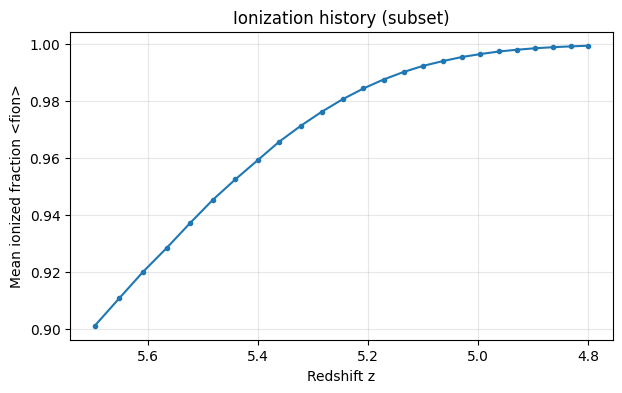

In [22]:
# Ionization history (set max_files=None for all snapshots)
max_files = 25
stats = mean_ionized_fraction(snapshots[:max_files] if max_files else snapshots, n_grid=200)
z = np.array([a for a, _ in stats])
x = np.array([b for _, b in stats])

plt.plot(z, x, marker='o', ms=3)
plt.gca().invert_xaxis()
plt.xlabel('Redshift z')
plt.ylabel('Mean ionized fraction <fion>')
plt.title('Ionization history (subset)' if max_files else 'Ionization history (all snapshots)')
plt.grid(alpha=0.3)
plt.show()

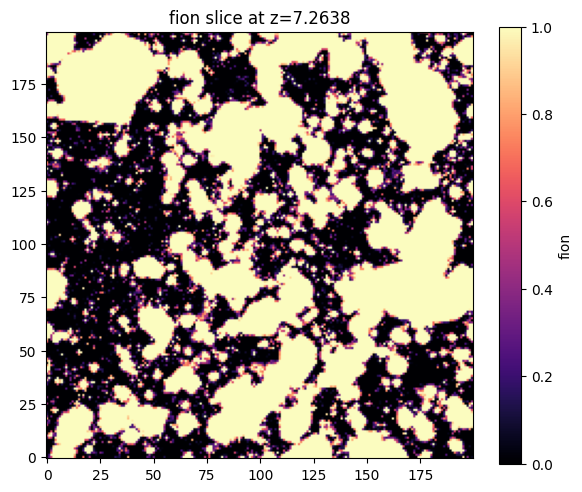

snapshot: gas_z=07.2638
mean fion: 0.5651465654373169


In [23]:
# Choose a snapshot and inspect fion slice
snap = snapshots[len(snapshots)//2]
fion = load_ionized_fraction(snap, n_grid=200, memmap=False).astype(np.float32)
z_snap = parse_redshift(snap)

mid = fion.shape[2] // 2
plt.figure(figsize=(6, 5))
im = plt.imshow(fion[:, :, mid], origin='lower', cmap='magma', vmin=0, vmax=1)
plt.colorbar(im, label='fion')
plt.title(f'fion slice at z={z_snap:.4f}')
plt.tight_layout()
plt.show()

print('snapshot:', snap.name)
print('mean fion:', float(fion.mean()))

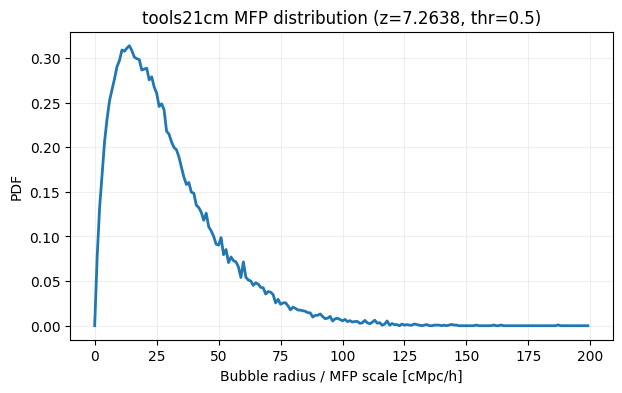

n_bins: 200
peak radius [cMpc/h]: 14.0


In [24]:
# tools21cm MFP bubble size distribution
threshold = 0.5
iterations = 200000

radii, pdf = t2c.bubble_stats.mfp(
    fion,
    xth=threshold,
    boxsize=200.0,
    iterations=iterations,
    verbose=False,
)
radii = np.asarray(radii)
pdf = np.asarray(pdf)

plt.plot(radii, pdf, lw=2)
plt.xlabel('Bubble radius / MFP scale [cMpc/h]')
plt.ylabel('PDF')
plt.title(f'tools21cm MFP distribution (z={z_snap:.4f}, thr={threshold})')
plt.grid(alpha=0.2)
plt.show()

print('n_bins:', radii.size)
print('peak radius [cMpc/h]:', float(radii[np.argmax(pdf)]))

In [25]:
# Save tools21cm result
out_dir = PROJECT_ROOT / 'results'
out_dir.mkdir(parents=True, exist_ok=True)
out = out_dir / f'notebook_tools21cm_mfp_z{z_snap:.4f}_thr{threshold:.2f}_iter{iterations}.npz'
np.savez(out, redshift=z_snap, threshold=threshold, iterations=iterations, radii_mpc_h=radii, pdf=pdf)
print('saved:', out)

saved: /home/aryana/Documents/GitHub/Lyman_alpha/results/notebook_tools21cm_mfp_z7.2638_thr0.50_iter200000.npz
